In [1]:
from os import listdir
import numpy as np

from ExistingAlgorithms.DRMetrics import matrix_metrics
from ExistingAlgorithms.Compare import compare

from AutoencoderAPI.loadAutoencoder import loadAutoencoder

from ExistingAlgorithms.MaxValue import max_value
from ExistingAlgorithms.Area import area
from ExistingAlgorithms.PCA import principal_component
from ExistingAlgorithms.SklearnAvailable import dimension_reduction

from ExistingAlgorithms.Plot import plot_1D, plot_traces

from sklearn.decomposition import PCA, KernelPCA, NMF
from sklearn.manifold import Isomap, TSNE, SpectralEmbedding, LocallyLinearEmbedding, MDS

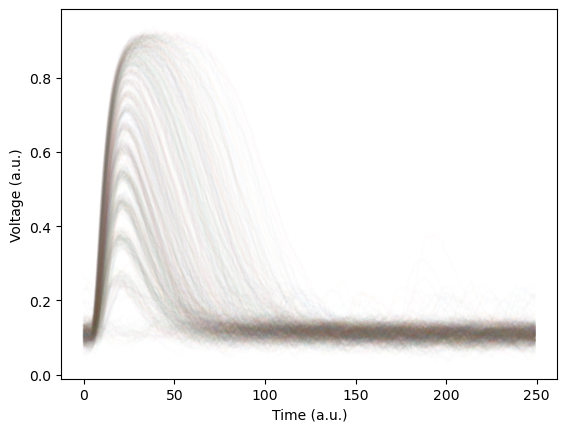

In [2]:
signal_size = 250
path = 'Datasets/NIST (250)/'

X = np.concatenate([np.fromfile(f"{path}{fileName}",dtype=np.float16).reshape(-1,signal_size) for fileName in listdir(path)])
X = X.astype("double")

plot_traces(np.copy(X)[::10])

### Max Value

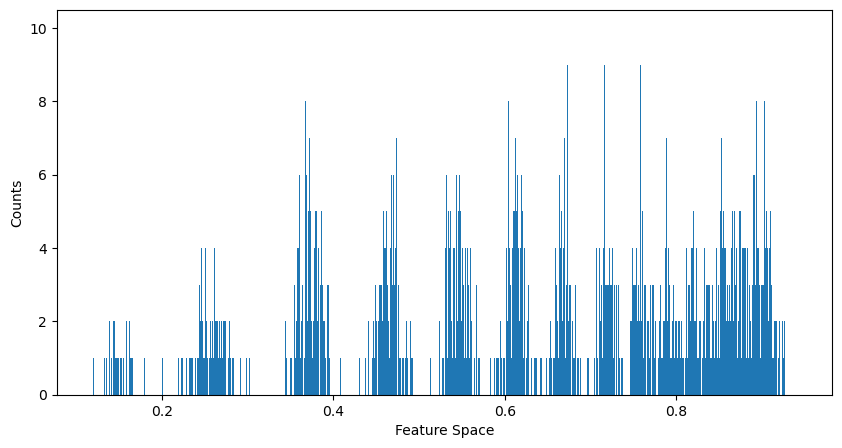

In [3]:
X_i_MAX, X_r_MAX, X_l_MAX = max_value(np.copy(X)[::10], filter=True)
plot_1D(X_l_MAX)

### Area

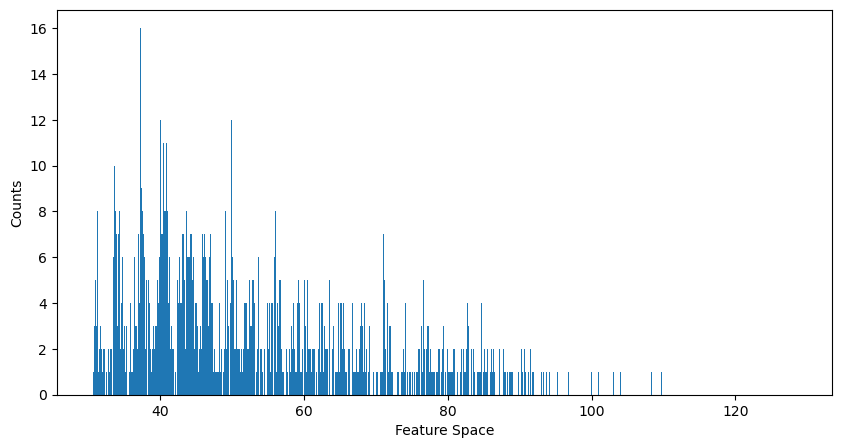

In [4]:
X_i_AREA, X_r_AREA, X_l_AREA = area(np.copy(X)[::10], filter=True)
plot_1D(X_l_AREA)

### Principal Component Analysis (PCA)

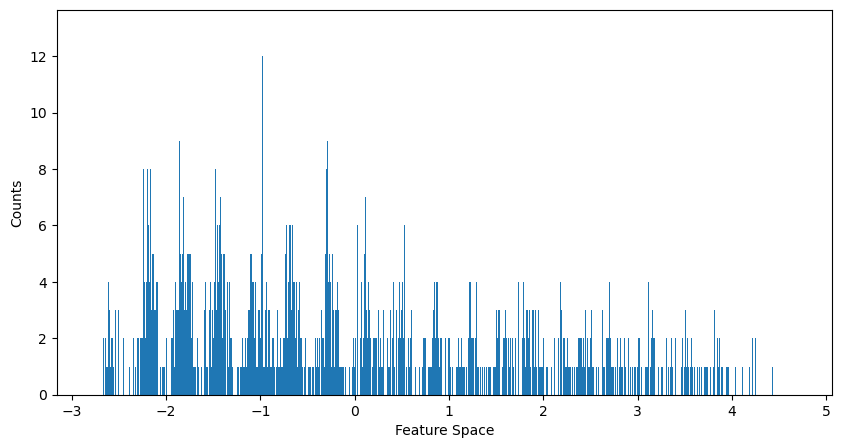

In [5]:
X_i_PCA, X_r_PCA, X_l_PCA = dimension_reduction(np.copy(X),PCA,n_components=1)
plot_1D(X_l_PCA)

### Kernel PCA (Polynomial)

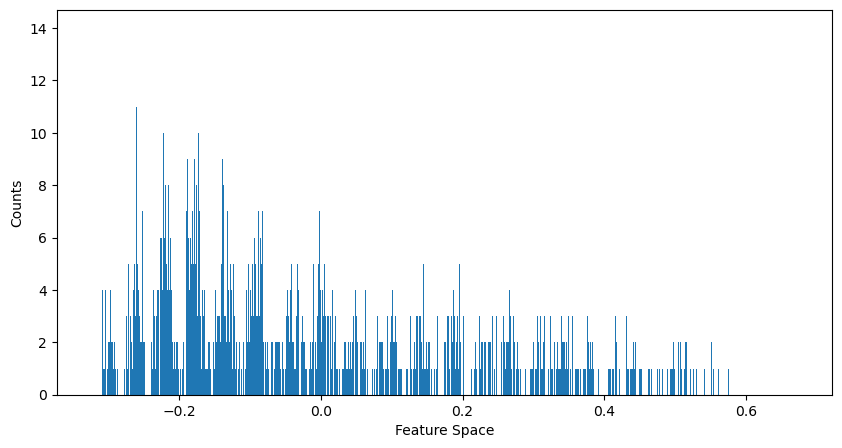

In [6]:
X_i_KPCA_P, X_r_KPCA_P, X_l_KPCA_P = dimension_reduction(np.copy(X),KernelPCA,n_components=1, kernel="poly", fit_inverse_transform=True)
plot_1D(X_l_KPCA_P)

### Kernel PCA (Radial basis function)

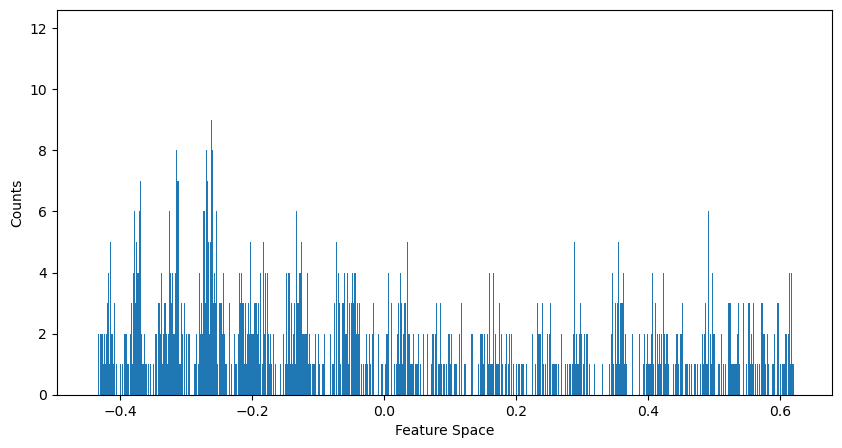

In [7]:
X_i_KPCA_RBF, X_r_KPCA_RBF, X_l_KPCA_RBF = dimension_reduction(np.copy(X),KernelPCA,n_components=1,kernel="rbf",gamma=0.02, fit_inverse_transform=True)
plot_1D(X_l_KPCA_RBF)

### Kernel PCA (Sigmoid)

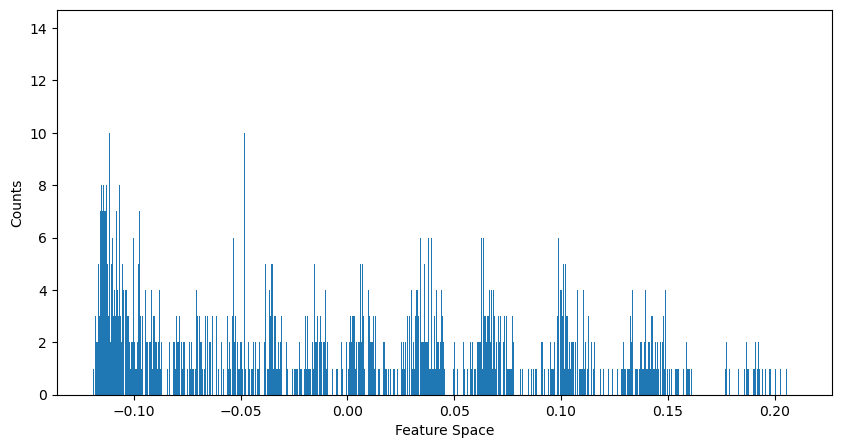

In [8]:
X_i_KPCA_S, X_r_KPCA_S, X_l_KPCA_S = dimension_reduction(np.copy(X),KernelPCA,n_components=1,kernel="sigmoid",gamma=0.02, fit_inverse_transform=True)
plot_1D(X_l_KPCA_S)

### Kernel PCA (Cosine)

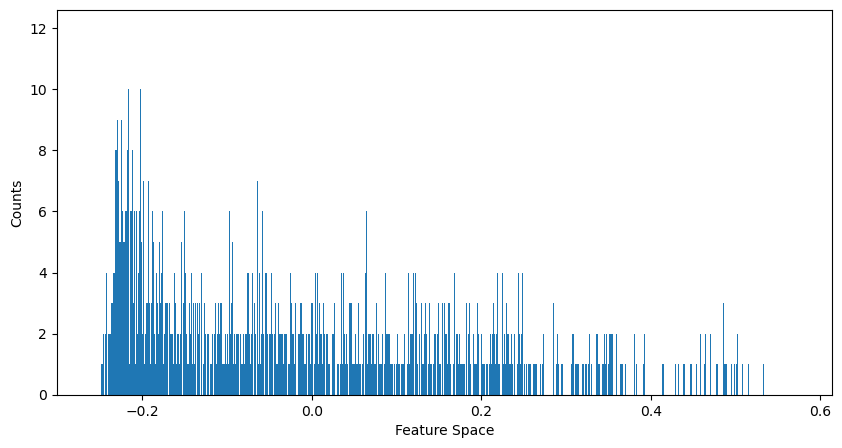

In [9]:
X_i_KPCA_C, X_r_KPCA_C, X_l_KPCA_C = dimension_reduction(np.copy(X),KernelPCA,n_components=1,kernel="cosine",gamma=0.02, fit_inverse_transform=True)
plot_1D(X_l_KPCA_C)

### t-distributed Stochastic Neighbor Embedding (t-SNE)

'TSNE' object has no attribute 'transform'


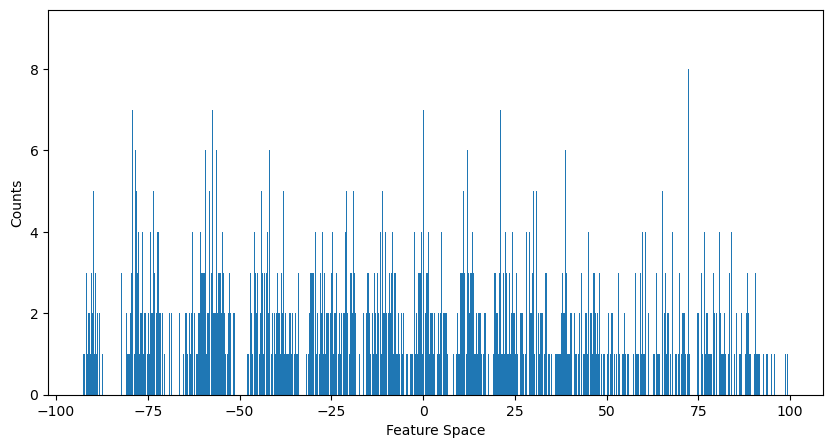

In [10]:
X_i_TSNE, X_r_TSNE, X_l_TSNE = dimension_reduction(np.copy(X),TSNE,n_components=1)
plot_1D(X_l_TSNE)

### Spectral Embedding 

In [11]:
#X_i_SE, X_r_SE, X_l_SE = dimension_reduction(np.copy(X),SpectralEmbedding,n_components=1)
#plot_1D(X_l_SE)

### Non-Negative Matrix Factorization (NMF)

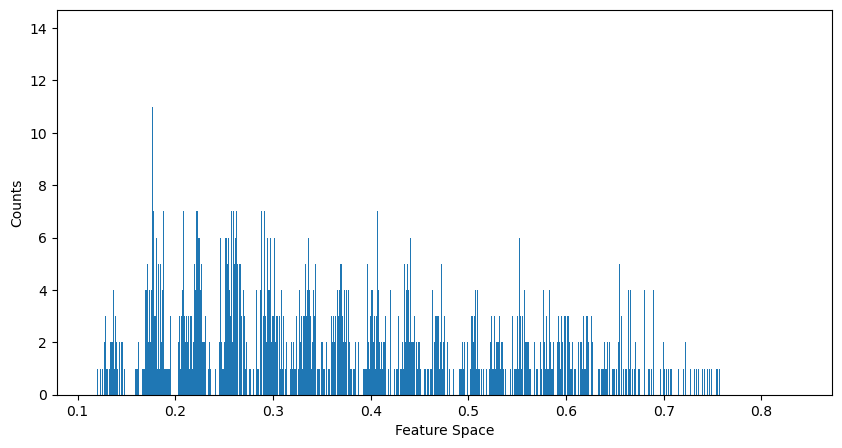

In [12]:
X_i_NMF, X_r_NMF, X_l_NMF = dimension_reduction(np.copy(X),NMF,n_components=1,alpha_W=0.1,random_state=42)
plot_1D(X_l_NMF)

### Isomap

'Isomap' object has no attribute 'inverse_transform'


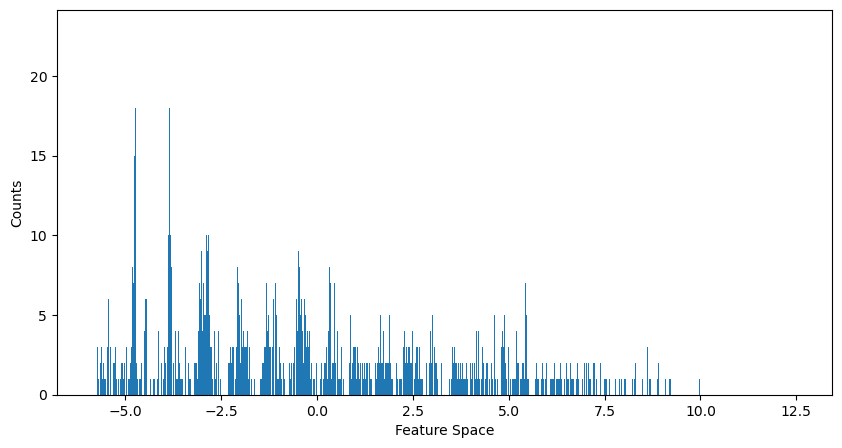

In [13]:
X_i_ISO, X_r_ISO, X_l_ISO = dimension_reduction(np.copy(X),Isomap,n_neighbors=20, n_components=1, eigen_solver="arpack")
plot_1D(X_l_ISO)

### Multidimensional scaling

In [14]:
#X_i_MS, X_r_MS, X_l_MS = dimension_reduction(np.copy(X),MDS,n_components=1,max_iter=10)
#plot_1D(X_l_MS)

### Locally Linear Embedding (LLE)

In [15]:
#X_i_LLE, X_r_LLE, X_l_LLE = dimension_reduction(np.copy(X),LocallyLinearEmbedding,n_components=1)
#plot_1D(X_l_LLE)

### Autoencoder



In [16]:
X_i_AUTO, X_r_AUTO, X_l_AUTO = loadAutoencoder(np.copy(X)[::10], 'run-2023-08-28-16-18/fold 0', filter=False)
plot_1D(X_l_AUTO)
print(np.shape(X_l_AUTO))

RuntimeError: Error(s) in loading state_dict for build_autoencoder:
	Missing key(s) in state_dict: "encoder.3.weight". 
	Unexpected key(s) in state_dict: "encoder.4.weight", "encoder.4.bias", "encoder.5.weight", "encoder.1.weight", "encoder.1.bias", "decoder.3.weight", "decoder.3.bias", "decoder.4.weight", "decoder.4.bias". 
	size mismatch for encoder.0.weight: copying a param with shape torch.Size([1, 1, 21]) from checkpoint, the shape in current model is torch.Size([50, 250]).
	size mismatch for encoder.0.bias: copying a param with shape torch.Size([1]) from checkpoint, the shape in current model is torch.Size([50]).
	size mismatch for encoder.2.weight: copying a param with shape torch.Size([50, 250]) from checkpoint, the shape in current model is torch.Size([1, 50]).
	size mismatch for encoder.2.bias: copying a param with shape torch.Size([50]) from checkpoint, the shape in current model is torch.Size([1]).

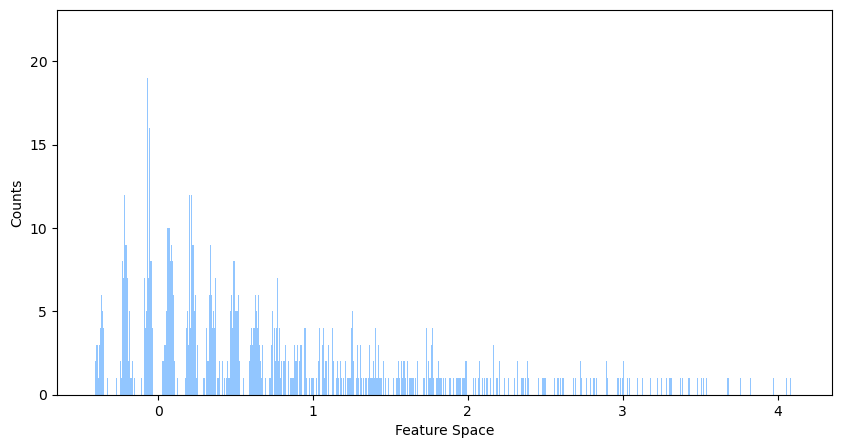

In [ ]:
X_i_AUTOF, X_r_AUTOF, X_l_AUTOF = loadAutoencoder(np.copy(X)[::10], 'run-2023-08-28-16-18/fold 0', filter=True)
plot_1D(X_l_AUTOF)

Method:   0%|          | 0/12 [00:00<?, ?it/s]

Max:   0%|          | 0/4 [00:00<?, ?it/s]

Area:   0%|          | 0/4 [00:00<?, ?it/s]

PCA:   0%|          | 0/4 [00:00<?, ?it/s]

K-PCA (Polynomial):   0%|          | 0/4 [00:00<?, ?it/s]

...

t-SNE:   0%|          | 0/4 [00:00<?, ?it/s]

NMF:   0%|          | 0/4 [00:00<?, ?it/s]

Isomap:   0%|          | 0/4 [00:00<?, ?it/s]

Autoencoder:   0%|          | 0/4 [00:00<?, ?it/s]

Autoencoder Filtered:   0%|          | 0/4 [00:00<?, ?it/s]

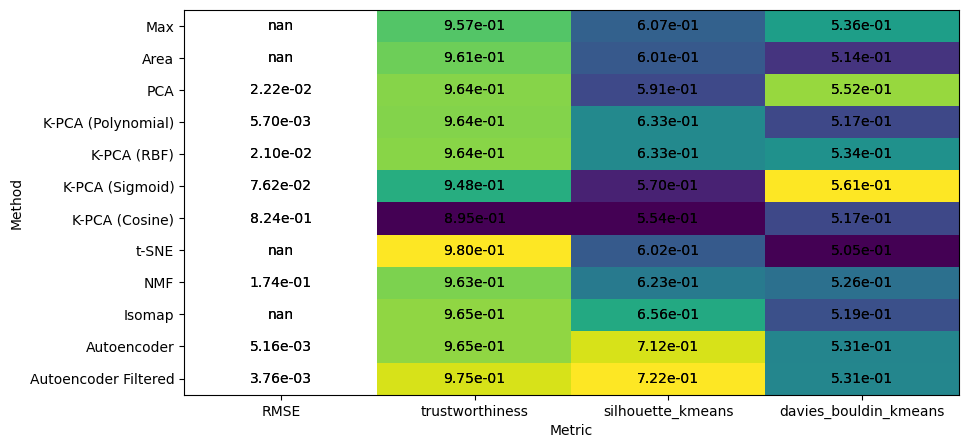

In [ ]:
config = {
    'min_cluster'   : 20,
    'max_cluster'   : 60
}
i = [X_i_MAX, X_i_AREA, X_i_PCA, X_i_KPCA_P, 
     X_i_KPCA_RBF, X_i_KPCA_S, X_i_KPCA_C, 
     X_i_TSNE, X_i_NMF, X_i_ISO, 
      X_i_AUTO, X_i_AUTOF]
l = [X_l_MAX, X_l_AREA, X_l_PCA, X_l_KPCA_P, 
     X_l_KPCA_RBF, X_l_KPCA_S, X_l_KPCA_C, 
     X_l_TSNE, X_l_NMF, X_l_ISO, 
      X_l_AUTO, X_l_AUTOF]
r = [X_r_MAX, X_r_AREA, X_r_PCA, X_r_KPCA_P, 
     X_r_KPCA_RBF, X_r_KPCA_S, X_r_KPCA_C, 
     X_r_TSNE, X_r_NMF, X_r_ISO, 
      X_r_AUTO, X_r_AUTOF]
methods = ['Max', 'Area', 'PCA', 'K-PCA (Polynomial)', 
           'K-PCA (RBF)', 'K-PCA (Sigmoid)',
           'K-PCA (Cosine)', 't-SNE',
           'NMF', 'Isomap',
           'Autoencoder', 'Autoencoder Filtered']

comp = compare(config)
comp.quality_metrics(i,r,l,methods)

In [ ]:
#matrix_metrics(i,l,r,methods)

  0%|          | 0/12 [00:00<?, ?it/s]

Construct the distance matrix
Residual Variance of the two distance matrices


KeyboardInterrupt: 